In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [8]:
train_data= fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

In [7]:
test_data=fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

In [9]:
X_train_text = train_data.data
y_train = train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [10]:
print("Training Documents :", len(X_train_text))
print("Testing documents: ", len(X_test_text))
print("Number of classes :", len(class_names))

Training Documents : 11314
Testing documents:  7532
Number of classes : 20


In [11]:
vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [13]:
print("Training feature matrix:", X_train.shape)
print("Training feature matrix:", X_test.shape)

Training feature matrix: (11314, 39115)
Training feature matrix: (7532, 39115)


In [21]:
mnb = MultinomialNB()

mnb.fit(
    X_train,
    y_train
)

y_pred_mnb = mnb.predict(X_test)

In [23]:
binary_vectorizer = CountVectorizer(
    stop_words="english",
    min_df=2,
    binary=True
)
X_train_binary = binary_vectorizer.fit_transform(
    X_train_text
)
X_test_binary = binary_vectorizer.transform(
    X_test_text
)

In [26]:
bnb = BernoulliNB()

bnb.fit(
    X_train_binary,
    y_train
)

y_pred_bnb = bnb.predict(
    X_test_binary
)


In [34]:
results = pd.DataFrame({
    "Model":[
        "Multinomial NB",
        "Bernoulli NB"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_mnb),
        accuracy_score(y_test, y_pred_bnb)
    ],

    "Precision":[
        precision_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        precision_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "Recall":[
        recall_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        recall_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ],

    "F1-Score":[
        f1_score(
            y_test,
            y_pred_mnb,
            average="macro"
        ),
        f1_score(
            y_test,
            y_pred_bnb,
            average="macro"
        )
    ]
})


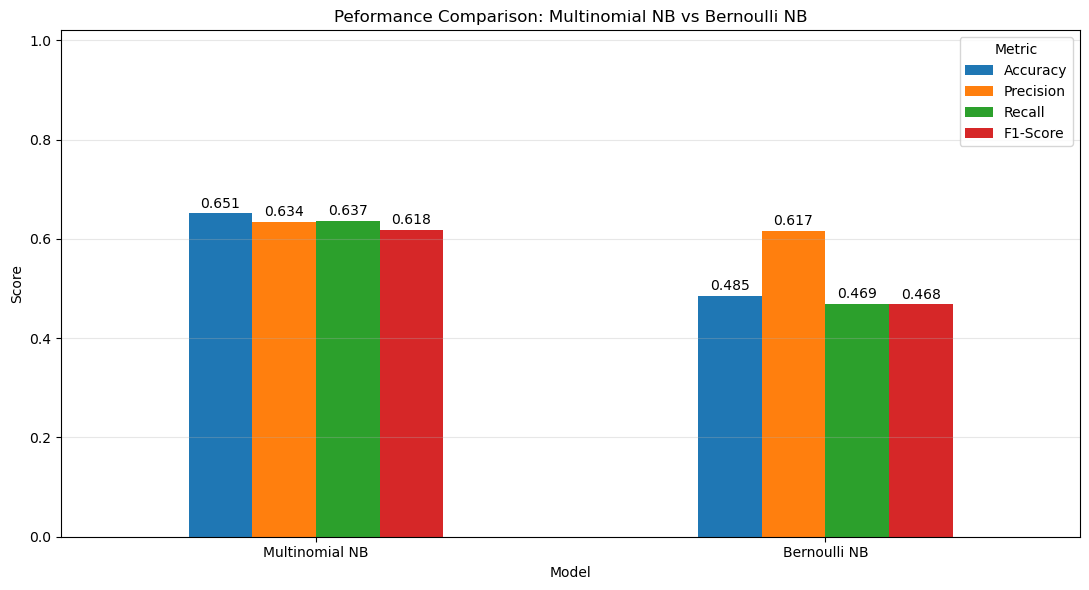

In [40]:
results_metrics=results[
    ["Model", "Accuracy", "Precision", "Recall" , "F1-Score"]
    ]

ax= results_metrics.set_index("Model").plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Peformance Comparison: Multinomial NB vs Bernoulli NB")

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.02)

plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(
    axis="y",
    alpha=0.3
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=2
    )
plt.tight_layout()
plt.show()